In [126]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

import pandas as pd
from sklearn.impute import SimpleImputer
from plotnine import *
from matplotlib import pyplot as plt
import numpy as np

import seaborn as sns
import tqdm as notebook_tqdm

import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [114]:
X_median = pd.read_csv('data/features_imputed_median.csv').iloc[:, 1:]
X_mice = pd.read_csv('data/features_imputed_mice.csv').iloc[:, 1:]
y = pd.read_csv('data/target.csv').iloc[:, 1:]

In [130]:
def train_models(X_train, X_test, y_train, y_test, reduced=False):
        
    models = {
        'dummy_classifier': DummyClassifier(strategy='most_frequent'),
        'logistic':LogisticRegression(),
        'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
        'random_forest': RandomForestClassifier(),
        'hist_gradient_boosting':HistGradientBoostingClassifier(),
        'gradient_boosting':GradientBoostingClassifier()
    }

    model_perfomance = {}
    trained_models = {}

    for model_name in models:
        model = models[model_name]
        model.fit(X_train, y_train)

        y_pred = model.predict_proba(X_test)

        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_pred, axis=1)
        
        model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                        'f1_score': f1_score(y_test, y_pred),
                                        'recall':recall_score(y_test, y_pred),
                                        'precision':precision_score(y_test, y_pred),
                                        'classification_report':classification_report(y_test, y_pred)}
        trained_models[model_name] = model
        
    #print(model_perfomance)
    results = pd.DataFrame(model_perfomance)
    display(results)

    return trained_models, results

In [116]:
def plot_permuted_importance(perm_imp):
    # Split top 8 vs the rest
    top8 = perm_imp.head(8)
    others = perm_imp.iloc[8:]

    # Aggregate the rest into one row
    others_row = pd.DataFrame([{
        'feature': f'All Other Features ({len(others)})',
        'importance': others['importance'].mean(),
        'std': others['std'].mean()
    }])

    # Combine and sort for plotting (smallest at top → largest at bottom for barh)
    plot_df = pd.concat([others_row, top8]).reset_index(drop=True)
    plot_df = plot_df.sort_values('importance', ascending=True)

    # Color: highlight top 8 vs the aggregated group
    colors = ['#b0b0b0'] + ['#1a6fa8'] * 8  # grey for "others", blue for top 8

    plt.figure(figsize=(10, 6))
    bars = plt.barh(
        plot_df['feature'], 
        plot_df['importance'],
        xerr=plot_df['std'],
        align='center',
        color=colors,
        edgecolor='white',
        height=0.6,
        error_kw=dict(ecolor='black', capsize=3, linewidth=0.8)
    )

    # Annotate importance values at end of each bar
    for bar, val in zip(bars, plot_df['importance']):
        plt.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=8)

    plt.title('Permutation Importance (Top 8 Features)', fontsize=12)
    plt.xlabel('Mean Accuracy Decrease', fontsize=11)
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def choose_important_features(X_test, y_test, trained_models, model_choice):
    result = permutation_importance(trained_models[model_choice], X_test, y_test, n_repeats=10, random_state=42)

    perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
        }).sort_values('importance', ascending=False)

    plot_permuted_importance(perm_imp)

    # Keep only features with positive importance
    important_features = perm_imp[perm_imp['importance'] > 0]['feature'].tolist()

    print(f"Kept {len(important_features)} of {X_test.shape[1]} features")

    return important_features

In [ ]:
def feature_selection_train_pipeline(X, y, reduced=False):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    trained_models, results = train_models(X_train, X_test, y_train, y_test, reduced=False)

    if not reduced:
        return X,trained_models, results

    important_features = choose_important_features(X_test, y_test, trained_models, 'gradient_boosting')

    return X[important_features], trained_models, results

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
/opt/anaconda3/lib/python3.12/site-packages/skle

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.665917,0.662667,0.682667,0.684250,0.681500
f1_score,0.00000,0.619748,0.658857,0.678596,0.679848,0.676102
recall,0.00000,0.544228,0.651174,0.669665,0.670165,0.664501
precision,0.00000,0.719604,0.666724,0.687767,0.689815,0.688115


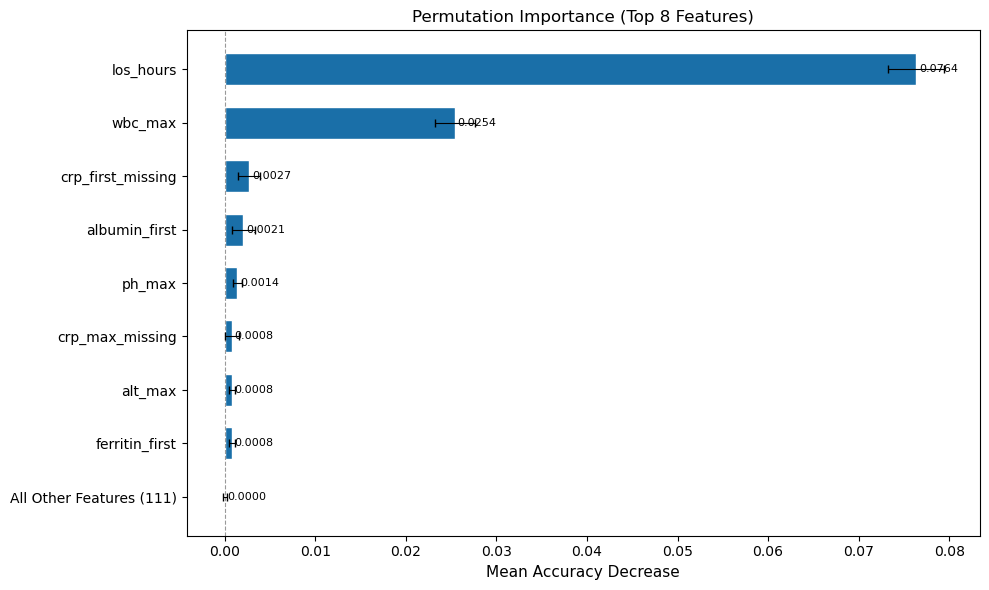

Kept 52 of 119 features


In [118]:
X_reduced, trained_models, results = feature_selection_train_pipeline(X_median, y, True)

In [123]:
X_reduced, trained_models, results = feature_selection_train_pipeline(X_reduced, y, False)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
/opt/anaconda3/lib/python3.12/site-packages/skle

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.663250,0.662667,0.680500,0.683583,0.680250
f1_score,0.00000,0.616858,0.658857,0.676674,0.678629,0.673085
recall,0.00000,0.541896,0.651174,0.668333,0.667833,0.658004
precision,0.00000,0.715889,0.666724,0.685226,0.689780,0.688873


## Lets Optimize this Model

In [124]:
trained_models

{'dummy_classifier': DummyClassifier(strategy='most_frequent'),
 'logistic': LogisticRegression(),
 'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
 'random_forest': RandomForestClassifier(),
 'hist_gradient_boosting': HistGradientBoostingClassifier(),
 'gradient_boosting': GradientBoostingClassifier()}

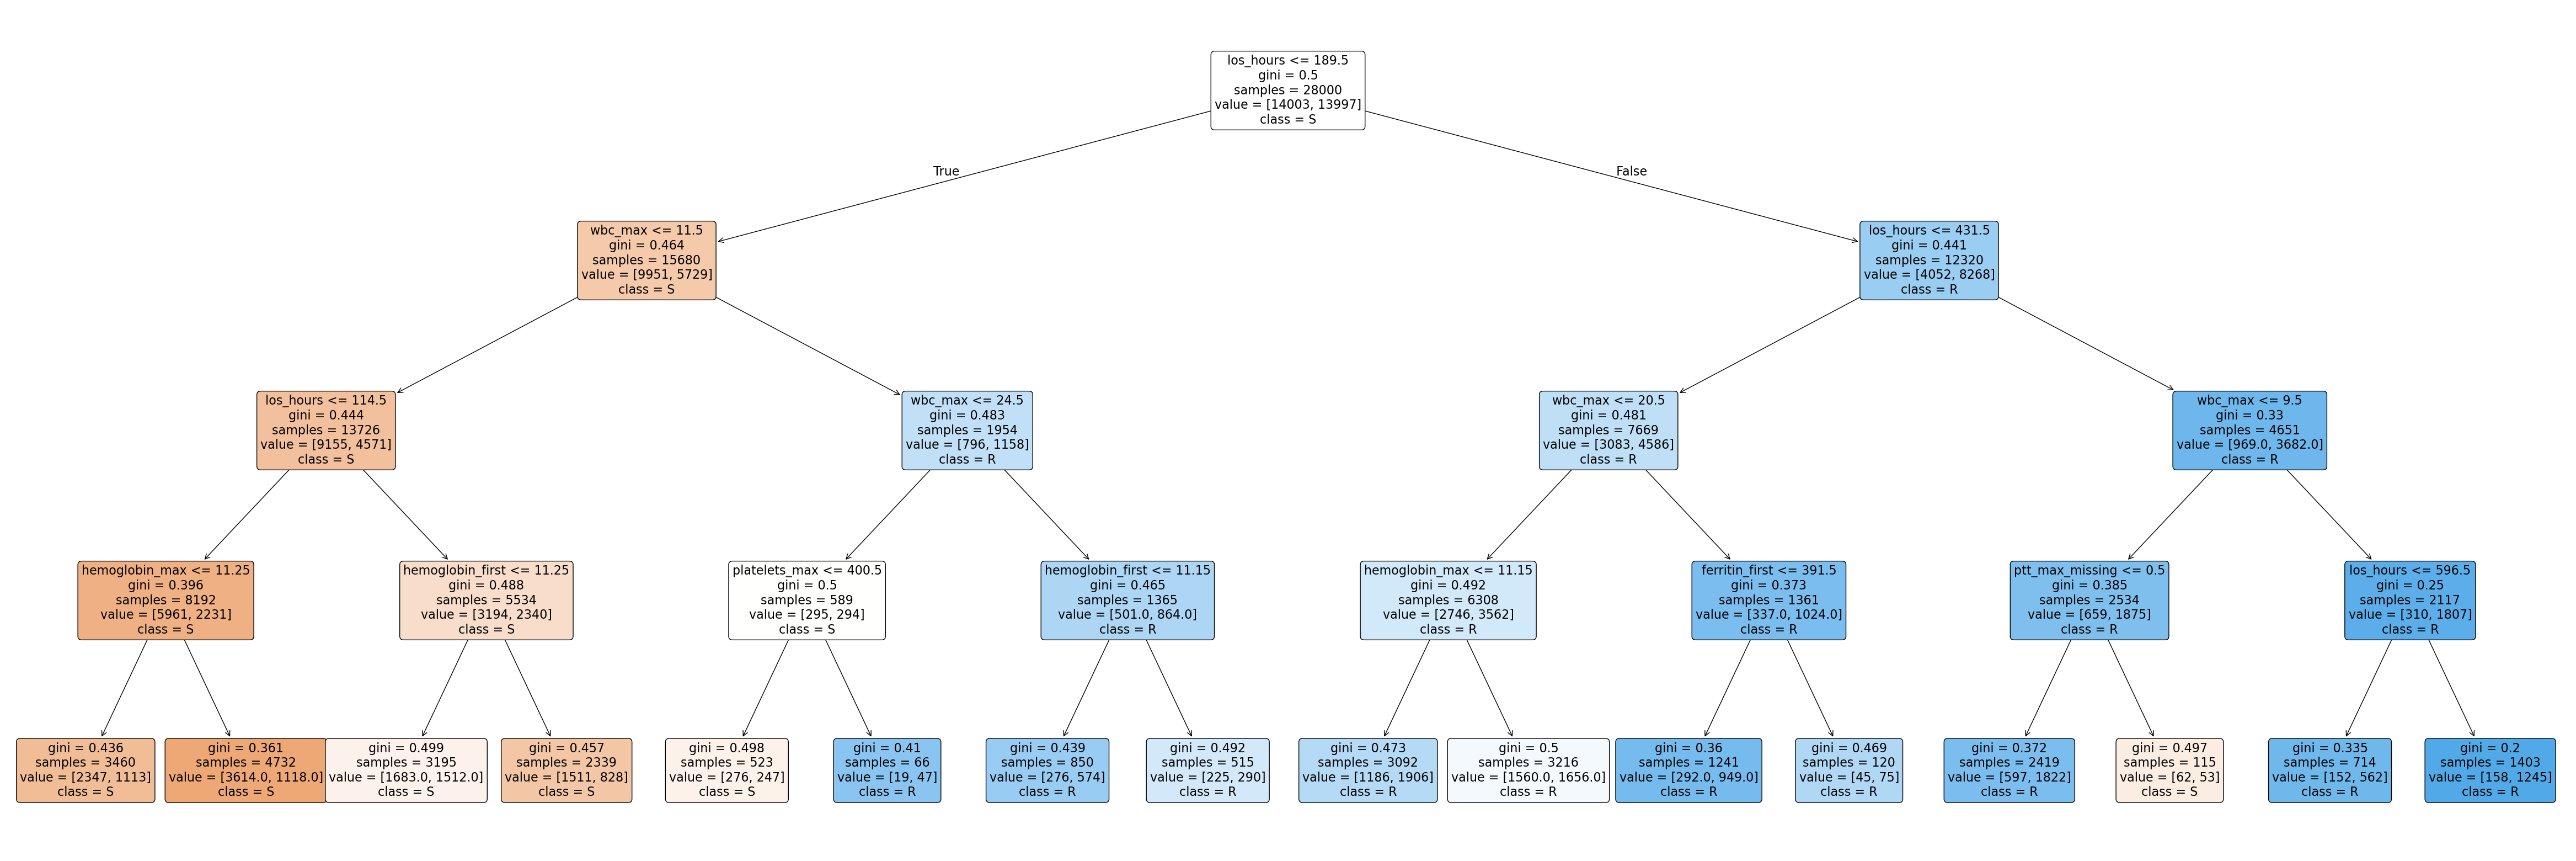

In [129]:
def plot_tree_from_output():
    fig, ax = plt.subplots(figsize=(60, 20))
    plot_tree(
        trained_models['decision_tree'],                            # your fitted DecisionTreeClassifier
        feature_names=X_reduced.columns.tolist(),
        class_names=['S', 'R'],
        filled=True,                    # colour nodes by class
        rounded=True,
        fontsize=16,
        ax=ax
    )
    plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_tree_from_output()

## Explainability

In [24]:
from ciu import CIU

In [ ]:


CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train_reduced)
CIU_amr.instance

In [26]:
rng = np.random.default_rng(seed=42)

indices_0 = np.where(y_test == 0)[0]
indices_1 = np.where(y_test == 1)[0]

instance_0 = X_test_reduced.iloc[[rng.choice(indices_0)]]
instance_1 = X_test_reduced.iloc[[rng.choice(indices_1)]]

In [27]:
instance_1

,los_hours,wbc_max,wbc_first_missing,albumin_first,platelets_max,crp_first_missing,wbc_max_missing,ph_first,hemoglobin_first,magnesium_first,...,alt_max,alt_max_missing,inr_first_missing,ptt_first_missing,calcium_first,bands_max_missing,ph_first_missing,ferritin_max,pco2_max_missing,ptt_max_missing
23683,203.0,21.016873,1.0,3.646574,418.0,0.0,1.0,5.0,11.4,1.8,...,9.0,0.0,0.0,0.0,9.4,1.0,0.0,60.0,1.0,0.0


In [28]:
7903 in y.index.tolist()

True

In [29]:
CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
display(CIUres_1)

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
los_hours,0.342823,0.930847,0.147704,Yes,0.632822,los_hours,0.313707,0.656530,[0],[203.0],0.5,None,None
wbc_max,0.157166,0.417369,-0.012987,Yes,0.632822,wbc_max,0.567226,0.724392,[1],[21.016872756653715],0.5,None,None
wbc_first_missing,0.027587,0.000000,-0.013793,Yes,0.632822,wbc_first_missing,0.632822,0.660409,[2],[1.0],0.5,None,None
albumin_first,0.136388,0.743368,0.033192,Yes,0.632822,albumin_first,0.531436,0.667824,[3],[3.6465742468382634],0.5,None,None
platelets_max,0.058069,1.000000,0.029035,Yes,0.632822,platelets_max,0.574753,0.632822,[4],[418.0],0.5,None,None
crp_first_missing,0.103907,1.000000,0.051954,Yes,0.632822,crp_first_missing,0.528915,0.632822,[5],[0.0],0.5,None,None
wbc_max_missing,0.000000,0.000000,-0.000000,Yes,0.632822,wbc_max_missing,0.632822,0.632822,[6],[1.0],0.5,None,None
ph_first,0.004616,0.000000,-0.002308,Yes,0.632822,ph_first,0.632822,0.637439,[7],[5.0],0.5,None,None
hemoglobin_first,0.066112,0.691453,0.012657,Yes,0.632822,hemoglobin_first,0.587109,0.653221,[8],[11.4],0.5,None,None
magnesium_first,0.013701,0.819202,0.004374,Yes,0.632822,magnesium_first,0.621598,0.635300,[9],[1.8],0.5,None,None


In [30]:
plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))]

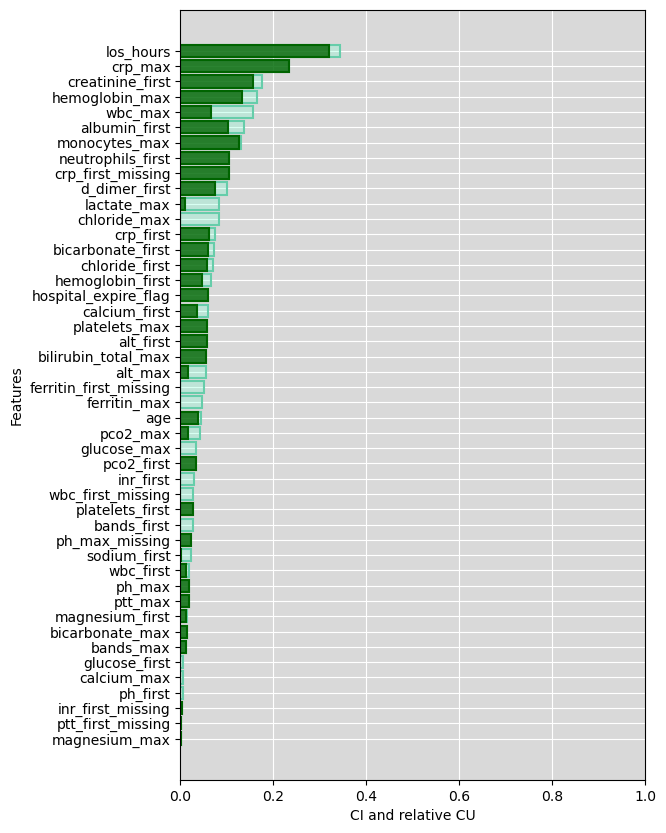

In [86]:

CIU_amr.plot_ciu(plot_df, plot_mode="overlap", figsize=(6,10))

In [32]:
plot_df

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
los_hours,0.342823,0.930847,0.147704,Yes,0.632822,los_hours,0.313707,0.656530,[0],[203.0],0.5,None,None
wbc_max,0.157166,0.417369,-0.012987,Yes,0.632822,wbc_max,0.567226,0.724392,[1],[21.016872756653715],0.5,None,None
wbc_first_missing,0.027587,0.000000,-0.013793,Yes,0.632822,wbc_first_missing,0.632822,0.660409,[2],[1.0],0.5,None,None
albumin_first,0.136388,0.743368,0.033192,Yes,0.632822,albumin_first,0.531436,0.667824,[3],[3.6465742468382634],0.5,None,None
platelets_max,0.058069,1.000000,0.029035,Yes,0.632822,platelets_max,0.574753,0.632822,[4],[418.0],0.5,None,None
crp_first_missing,0.103907,1.000000,0.051954,Yes,0.632822,crp_first_missing,0.528915,0.632822,[5],[0.0],0.5,None,None
ph_first,0.004616,0.000000,-0.002308,Yes,0.632822,ph_first,0.632822,0.637439,[7],[5.0],0.5,None,None
hemoglobin_first,0.066112,0.691453,0.012657,Yes,0.632822,hemoglobin_first,0.587109,0.653221,[8],[11.4],0.5,None,None
magnesium_first,0.013701,0.819202,0.004374,Yes,0.632822,magnesium_first,0.621598,0.635300,[9],[1.8],0.5,None,None
bicarbonate_first,0.072031,0.832154,0.023926,Yes,0.632822,bicarbonate_first,0.572881,0.644912,[10],[24.0],0.5,None,None


In [33]:
resistant_indices = rng.choice(indices_1, 4)

In [34]:
def get_ciu_results(resistant_indices):
    CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train_reduced)
    CIU_amr.instance

    ciu_results = {}
    for i in resistant_indices:
        instance_1 = X_test_reduced.iloc[[i]]
        CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
        plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))] #Removes the really small values, pretty much because I have in some cases 119 features
        ciu_results[i]=plot_df #Cleaner datagframe for plotting

    return ciu_results

In [42]:
def plot_ciu_instances(ciu_results):
    keys = list(ciu_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 20))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        result = ciu_results[key]
        
        # plot_ciu renders internally — grab the figure it just created
        CIU_amr.plot_ciu(result, plot_mode="overlap", figsize=(6, 12))
        p = plt.gcf()  # <-- capture whatever figure is currently active
        
        # Capture it to a buffer
        buf = io.BytesIO()
        p.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close(p)  # close the internal figure
        
        # Paste into the subplot as an image
        img = mpimg.imread(buf)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Instance {key}")

    # Hide unused axes
    for j in range(len(keys), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=1.0)
    plt.show()
    return

In [36]:
ciu_results = get_ciu_results(resistant_indices)

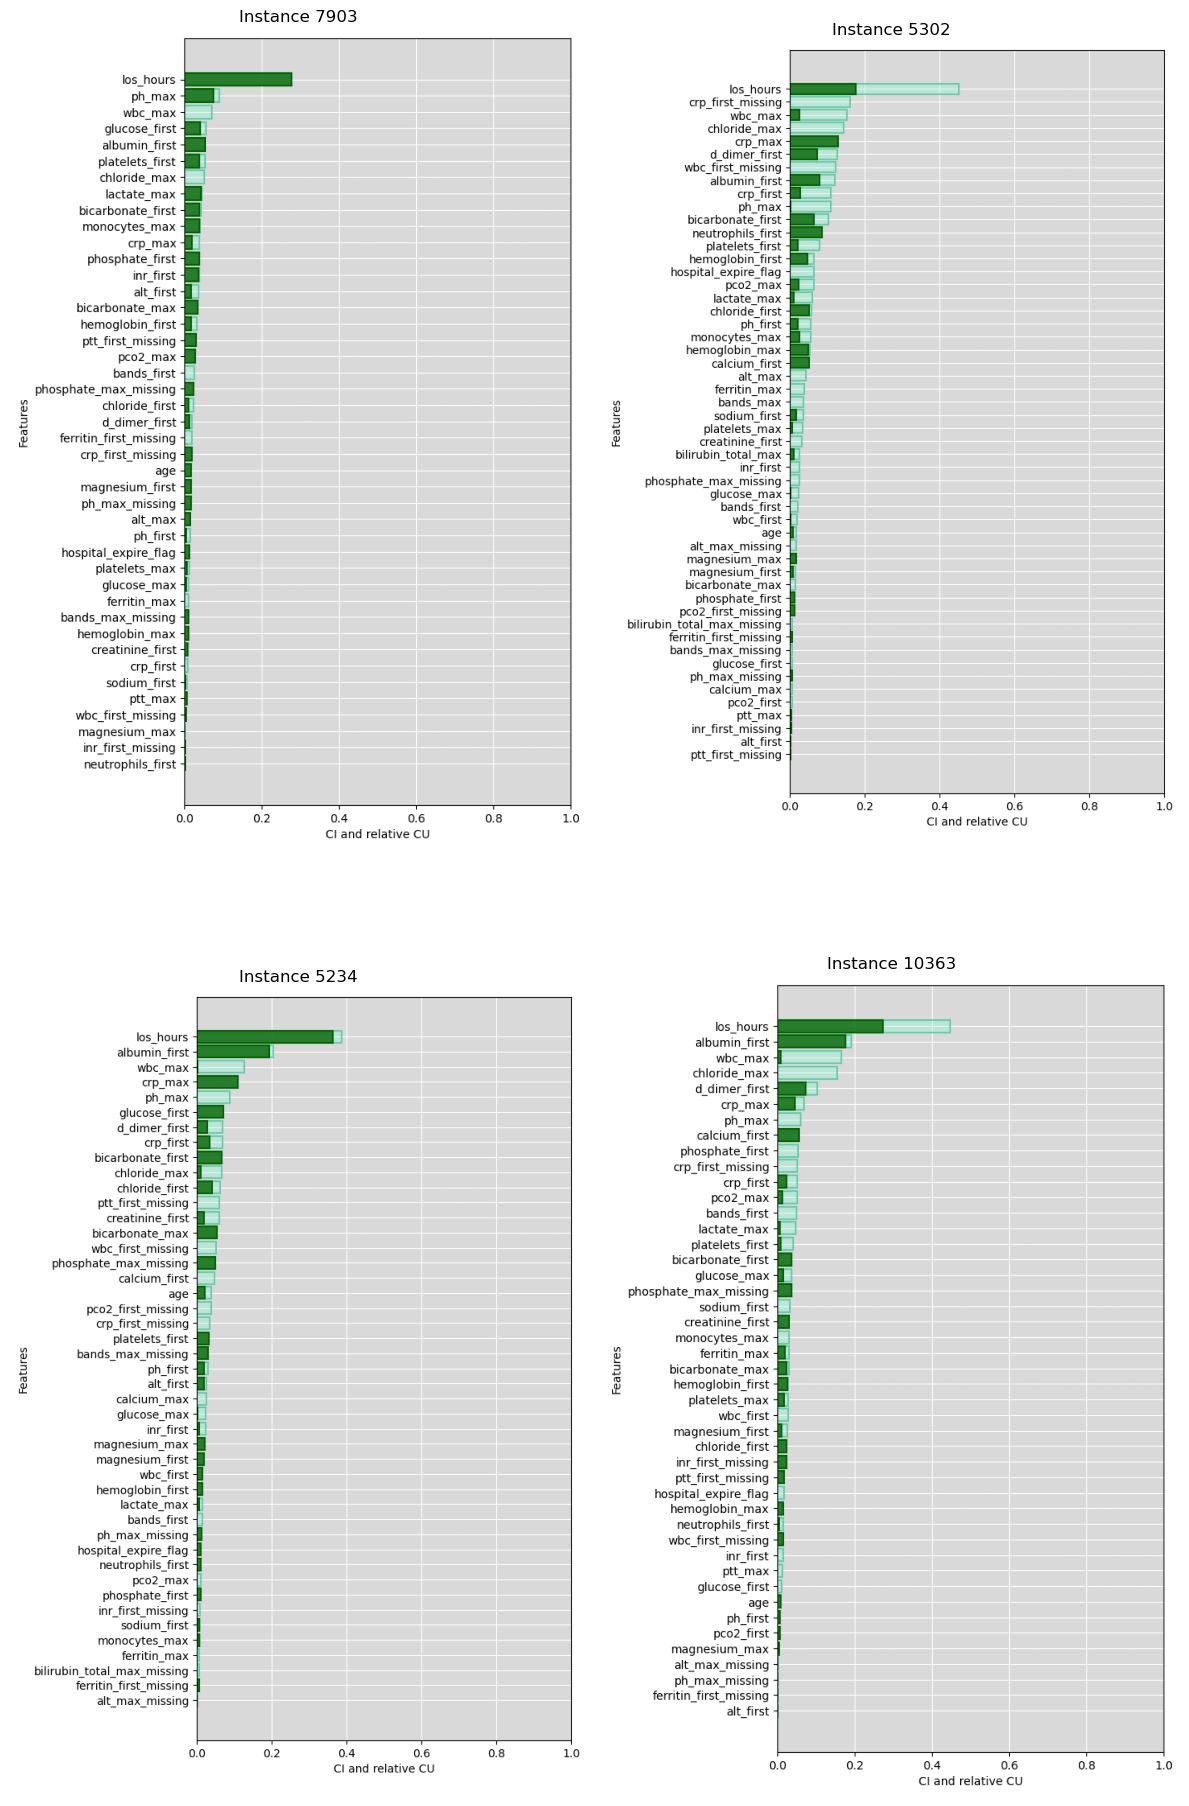

In [87]:
plot_ciu_instances(ciu_results)